<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Serena Saggion


# Introducción


# Teoría


# Procedimiento

## Ejercicio 1
Cada caso posee su respectivo período, número de muestras, y si se trata de una señal de potencia o energía según corresponda.

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def mi_sen(vmax, dc, ff, ph, nn, fs):
    Ts = 1/fs
    tt = np.arange(nn) * Ts
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

def cuadrada(A, f, nn, fs):
    tt = np.arange(nn) / fs
    xx = A * np.sign(np.sin(2*np.pi*f*tt))
    return tt, xx

def escalon(A, t0, nn, fs):
    tt = np.arange(nn) / fs
    xx = np.zeros(nn)
    xx[tt >= t0] = A
    return tt, xx

def pulso_rect(A, t0, tf, nn, fs):
    tt, xu1 = escalon(A, t0, nn, fs)
    tt, xu2 = escalon(A, tf, nn, fs)
    xc = xu1 - xu2
    return tt, xc

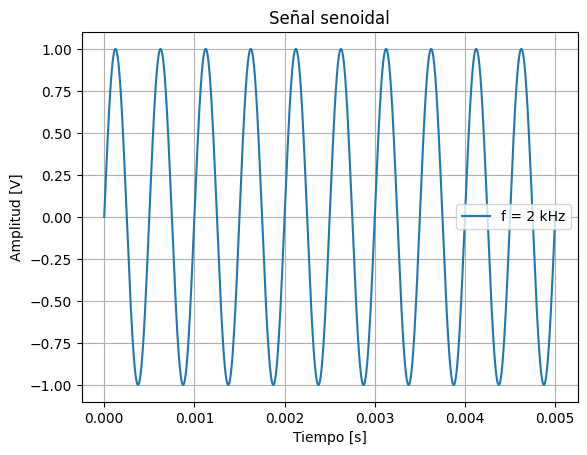

In [19]:
# Parámetros
fs = 2000001
N = 10000

# 1) Señal original de 2 kHz
tt1, x1 = mi_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N, fs=fs)

# Gráfico 1
plt.figure()
plt.plot(tt1, x1, label="f = 2 kHz")
plt.title("Señal senoidal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

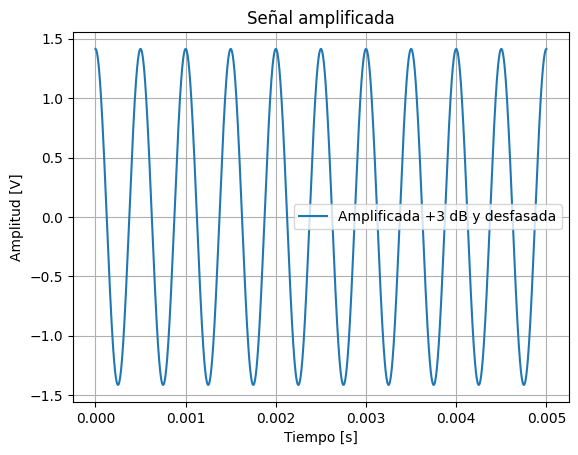

In [20]:
# 2) Misma señal amplificada +3 dB y desfasada en pi/2
fs2 = 2000001
N2 = 10000
tt2, x2 = mi_sen(vmax=np.sqrt(2), dc=0, ff=2000, ph=np.pi/2, nn=N2, fs=fs2)

# Gráfico 2
plt.figure()
plt.plot(tt2, x2, label="Amplificada +3 dB y desfasada")
plt.title("Señal amplificada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()


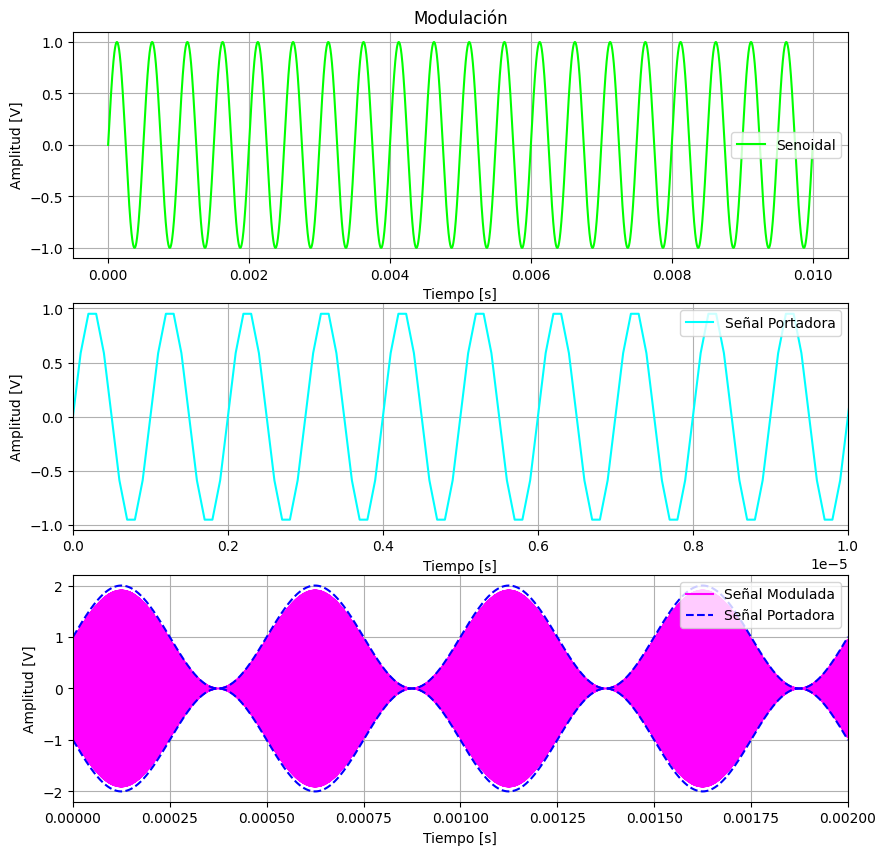

In [21]:
# 3) Modulación
# Parámetros
fs3 = 10000000
N3 = 100000

#Señal original
tt3, xx1 = mi_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N3, fs=fs3)
#Portadora
tt3, xm = mi_sen(vmax=1, dc=0, ff=1000000, ph=0, nn=N3, fs=fs3)
# Señal modulada
x3 = (1 + xx1) * xm

# Gráfico 3
plt.figure(figsize=(10,10))
plt.subplot(3, 1,1)
plt.title("Modulación")
plt.plot(tt3, xx1, label="Senoidal", color="lime")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()

plt.subplot(3, 1,2)
plt.plot(tt3,xm, label="Señal Portadora", color="aqua")
plt.xlim(0, 0.00001) #zoom
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()

plt.subplot(3, 1,3)
plt.plot(tt3,x3, label="Señal Modulada", color="fuchsia")
plt.plot(tt3,(1+xx1), 'b--', label="Señal Portadora")
plt.plot(tt3,-(1+xx1), 'b--')
plt.xlim(0, 0.002) #zoom
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

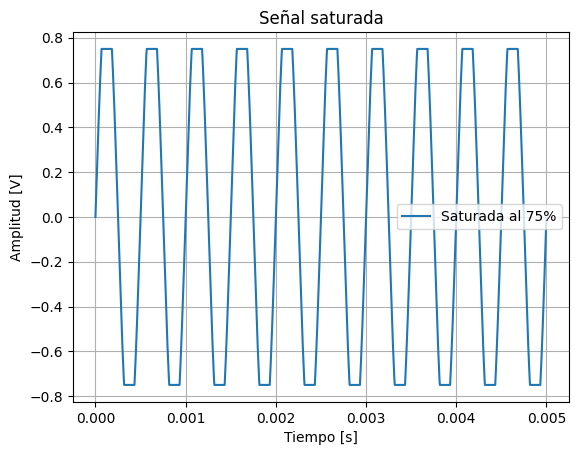

In [22]:
# 4) Señal saturada al 75%
fs4 = 2000001
N4 = 10000
tt4, x4 = mi_sen(vmax=1, dc=0, ff=2000, ph=0, nn=N4, fs=fs4)
x4 = np.clip(x4, -0.75, 0.75)

# Gráfico 4
plt.figure()
plt.plot(tt4, x4, label="Saturada al 75%")
plt.title("Señal saturada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

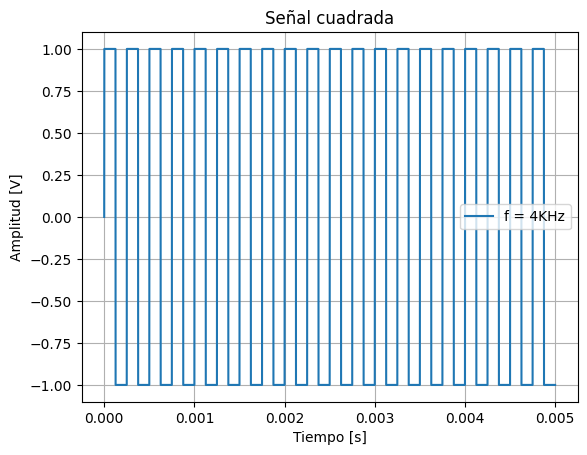

In [23]:
# 5) Señal cuadrada
fs5 = 2000001
N5 = 10000
tt5,x5=cuadrada(A=1, f=4000, nn=N5, fs=fs5)

# Gráfico 5
plt.figure()
plt.plot(tt5, x5, label="f = 4KHz")
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

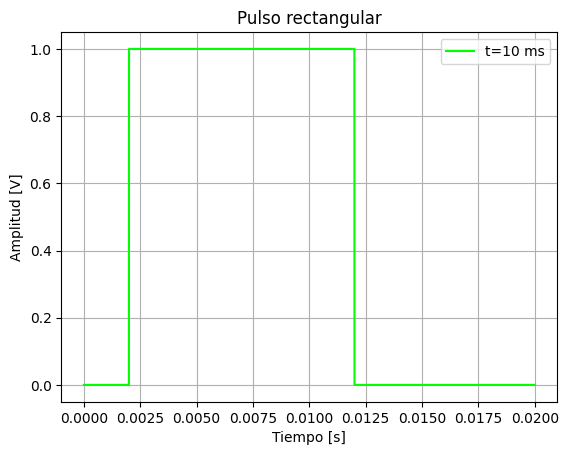

In [24]:
# 6) Pulso rectangular
fs6 = 2000001
N6 = 40000
tt6, x6 = pulso_rect(A=1, t0=0.002, tf=0.012, nn=N6, fs=fs6)

# Gráfico 6
plt.figure()
plt.plot(tt6, x6, label="t=10 ms", color="lime")
plt.title("Pulso rectangular")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid()
plt.show()

# Análisis de Resultados

# Conclusión